In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (50000, 32, 32, 3), Test shape: (10000, 32, 32, 3)
Label shape: (50000, 1)


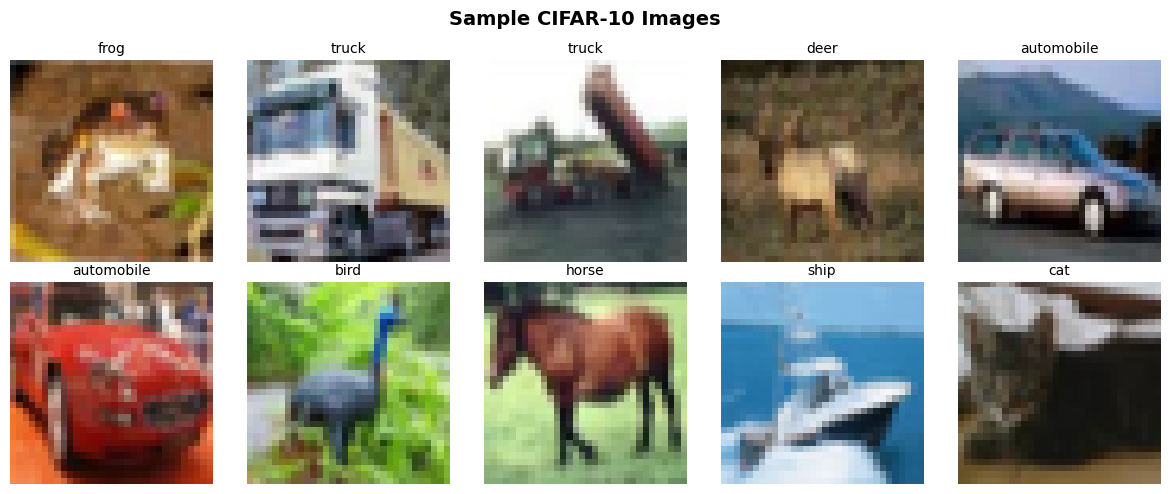

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")
print(f"Label shape: {y_train.shape}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i][0]], fontsize=10)
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)  # (50000, 3072)
x_test_flat  = x_test_norm.reshape(x_test_norm.shape[0], -1)

print(f"Normalized Train: {x_train_norm.shape}")
print(f"Flattened Train (for ANN): {x_train_flat.shape}")

Normalized Train: (50000, 32, 32, 3)
Flattened Train (for ANN): (50000, 3072)


### ANN

In [ ]:
def build_ann(input_dim=3072, num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(1024, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(num_classes, activation='softmax')
    ], name="ANN_Model")
    return model

ann_model = build_ann()
ann_model.summary()

Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,234 (14.66 MB)

 Trainable params: 3,840,650 (14.65 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [ ]:
ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ann = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

ann_history = ann_model.fit(
    x_train_flat, y_train_cat,
    validation_split=0.1,
    epochs=50,
    batch_size=256,
    callbacks=callbacks_ann,
    verbose=1
)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.2861 - loss: 2.0560 - val_accuracy: 0.3692 - val_loss: 1.7511 - learning_rate: 0.0010
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3656 - loss: 1.7750 - val_accuracy: 0.3080 - val_loss: 2.0170 - learning_rate: 0.0010
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3984 - loss: 1.6767 - val_accuracy: 0.3208 - val_loss: 1.8645 - learning_rate: 0.0010
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4178 - loss: 1.6271 - val_accuracy: 0.3144 - val_loss: 1.9101 - learning_rate: 0.0010
Epoch 5/50
172/176 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4275 - loss: 1.6045
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4300 - loss: 1.5974 - val_accuracy: 0.3690 - val_loss: 1.7648 - learning_rate: 0.0010
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4460 - loss: 1.5441 -


ANN Test Accuracy : 54.45%
ANN Test Loss     : 1.2826


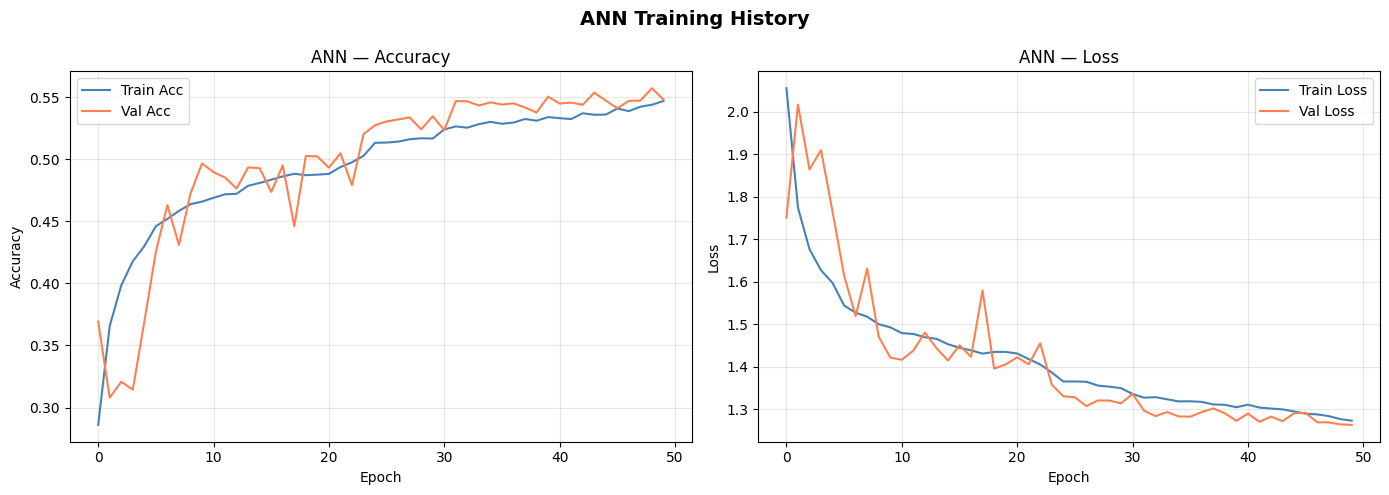

In [ ]:
ann_loss, ann_acc = ann_model.evaluate(x_test_flat, y_test_cat, verbose=0)
print(f"\nANN Test Accuracy : {ann_acc*100:.2f}%")
print(f"ANN Test Loss     : {ann_loss:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ann_history.history['accuracy'],    label='Train Acc', color='steelblue')
ax1.plot(ann_history.history['val_accuracy'],label='Val Acc',   color='coral')
ax1.set_title('ANN — Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ann_history.history['loss'],     label='Train Loss', color='steelblue')
ax2.plot(ann_history.history['val_loss'], label='Val Loss',   color='coral')
ax2.set_title('ANN — Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('ANN Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## CNN

In [ ]:
def build_cnn(input_shape=(32,32,3), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')

    ], name="CNN_Model")
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="augmentation")

train_dataset = tf.data.Dataset.from_tensor_slices((x_train_norm, y_train_cat))
train_dataset = (train_dataset
    .shuffle(50000)
    .batch(128)
    .map(lambda x, y: (data_augmentation(x, training=True), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (x_train_norm[:5000], y_train_cat[:5000])
).batch(128).prefetch(tf.data.AUTOTUNE)

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=60,
    callbacks=callbacks_cnn,
    verbose=1
)

Epoch 1/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.3587 - loss: 1.9284 - val_accuracy: 0.3412 - val_loss: 1.9009 - learning_rate: 0.0010
Epoch 2/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.4820 - loss: 1.4378 - val_accuracy: 0.4674 - val_loss: 1.6299 - learning_rate: 0.0010
Epoch 3/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.5413 - loss: 1.2773 - val_accuracy: 0.5728 - val_loss: 1.2650 - learning_rate: 0.0010
Epoch 4/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5799 - loss: 1.1748 - val_accuracy: 0.5580 - val_loss: 1.3760 - learning_rate: 0.0010
Epoch 5/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.6099 - loss: 1.0981 - val_accuracy: 0.6074 - val_loss: 1.1987 - learning_rate: 0.0010
Epoch 6/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.6350 - loss: 1.0355 - val_accuracy: 0.6756 - val_loss: 0.9182 - learning_rate: 0.0010
Epoch 7/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.6568 - l


CNN Test Accuracy : 84.18%
CNN Test Loss     : 0.4775


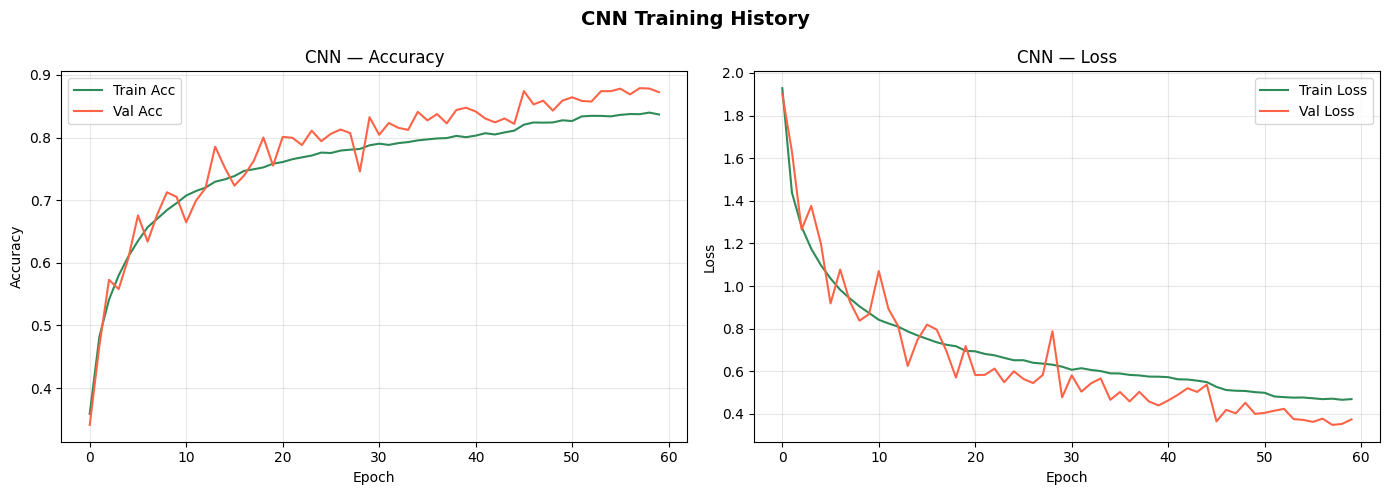

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"\nCNN Test Accuracy : {cnn_acc*100:.2f}%")
print(f"CNN Test Loss     : {cnn_loss:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cnn_history.history['accuracy'],    label='Train Acc', color='seagreen')
ax1.plot(cnn_history.history['val_accuracy'],label='Val Acc',   color='tomato')
ax1.set_title('CNN — Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(cnn_history.history['loss'],     label='Train Loss', color='seagreen')
ax2.plot(cnn_history.history['val_loss'], label='Val Loss',   color='tomato')
ax2.set_title('CNN — Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CNN Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


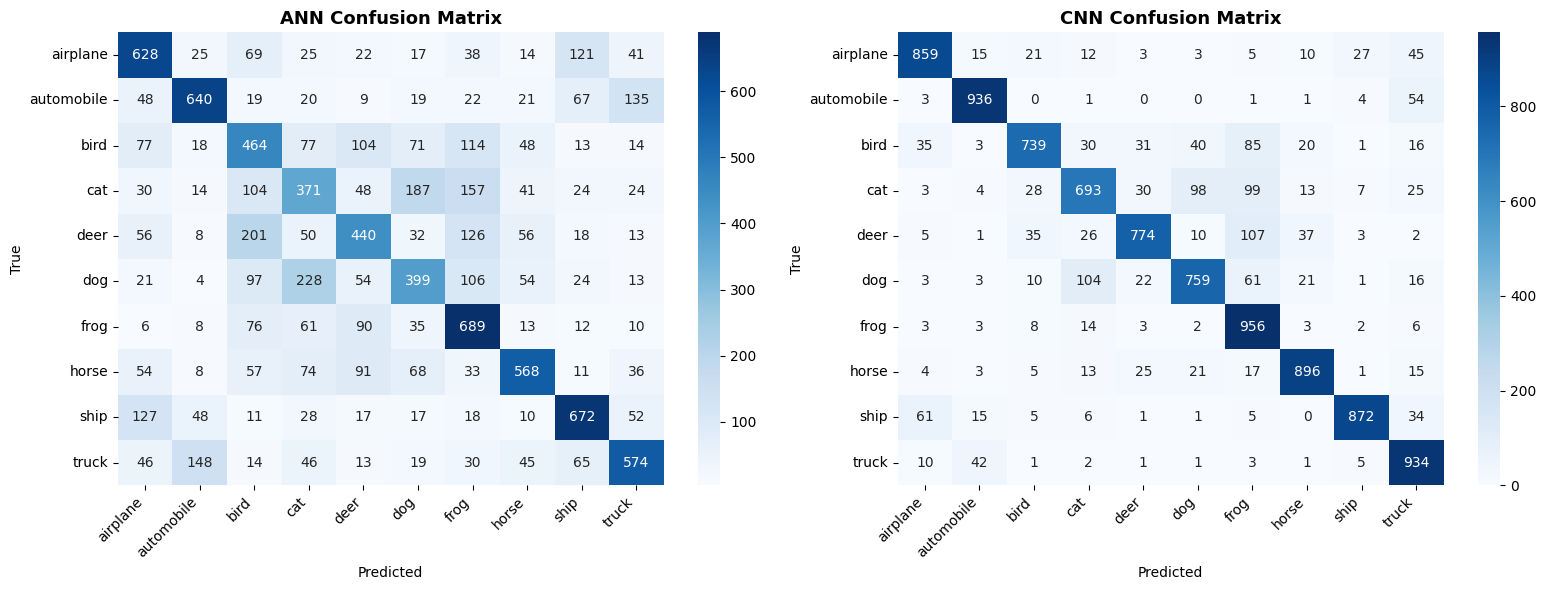

In [ ]:
y_pred_ann = np.argmax(ann_model.predict(x_test_flat), axis=1)
y_pred_cnn = np.argmax(cnn_model.predict(x_test_norm), axis=1)
y_true     = y_test.flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(axes,
                              [y_pred_ann, y_pred_cnn],
                              ["ANN Confusion Matrix", "CNN Confusion Matrix"]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 55)
print("       ANN — Classification Report")
print("=" * 55)
print(classification_report(y_true, y_pred_ann, target_names=class_names))

print("=" * 55)
print("       CNN — Classification Report")
print("=" * 55)
print(classification_report(y_true, y_pred_cnn, target_names=class_names))

       ANN — Classification Report
              precision    recall  f1-score   support

    airplane       0.57      0.63      0.60      1000
  automobile       0.69      0.64      0.67      1000
        bird       0.42      0.46      0.44      1000
         cat       0.38      0.37      0.37      1000
        deer       0.50      0.44      0.47      1000
         dog       0.46      0.40      0.43      1000
        frog       0.52      0.69      0.59      1000
       horse       0.65      0.57      0.61      1000
        ship       0.65      0.67      0.66      1000
       truck       0.63      0.57      0.60      1000

    accuracy                           0.54     10000
   macro avg       0.55      0.54      0.54     10000
weighted avg       0.55      0.54      0.54     10000

       CNN — Classification Report
              precision    recall  f1-score   support

    airplane       0.87      0.86      0.87      1000
  automobile       0.91      0.94      0.92      1000
        

Model Test Accuracy Test Loss Parameters        Input Type Spatial Aware Augmentation
  ANN        54.45%    1.2826  3,844,234  Flattened (3072)            No           No
  CNN        84.18%    0.4775    816,938 Spatial (32×32×3)           Yes          Yes


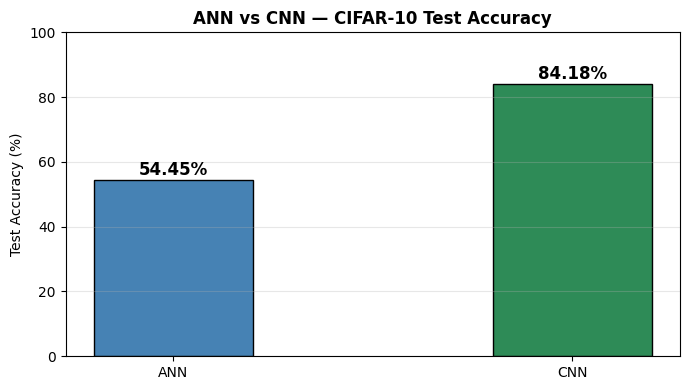

In [ ]:
ann_params = ann_model.count_params()
cnn_params = cnn_model.count_params()

metrics = {
    'Model':          ['ANN', 'CNN'],
    'Test Accuracy':  [f"{ann_acc*100:.2f}%", f"{cnn_acc*100:.2f}%"],
    'Test Loss':      [f"{ann_loss:.4f}", f"{cnn_loss:.4f}"],
    'Parameters':     [f"{ann_params:,}", f"{cnn_params:,}"],
    'Input Type':     ['Flattened (3072)', 'Spatial (32×32×3)'],
    'Spatial Aware':  ['No', 'Yes'],
    'Augmentation':   ['No', 'Yes'],
}

import pandas as pd
df = pd.DataFrame(metrics)
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['ANN', 'CNN'], [ann_acc*100, cnn_acc*100],
              color=['steelblue', 'seagreen'], width=0.4, edgecolor='black')
for bar, val in zip(bars, [ann_acc*100, cnn_acc*100]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylim(0, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('ANN vs CNN — CIFAR-10 Test Accuracy', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step


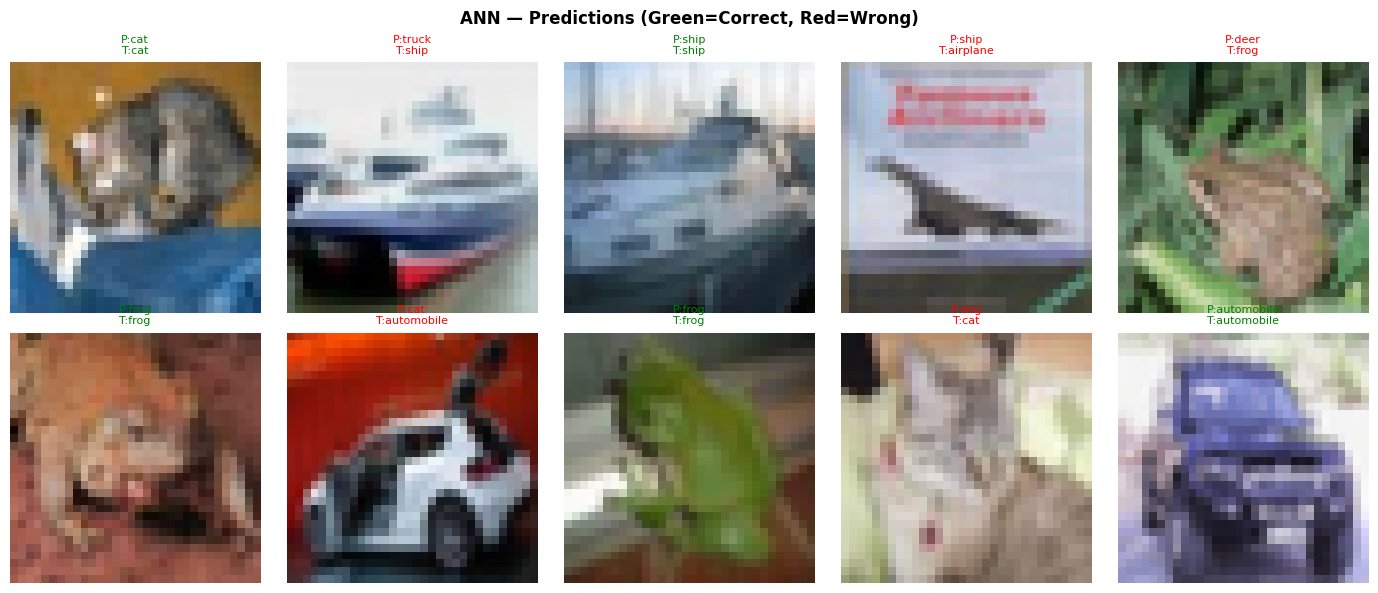

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


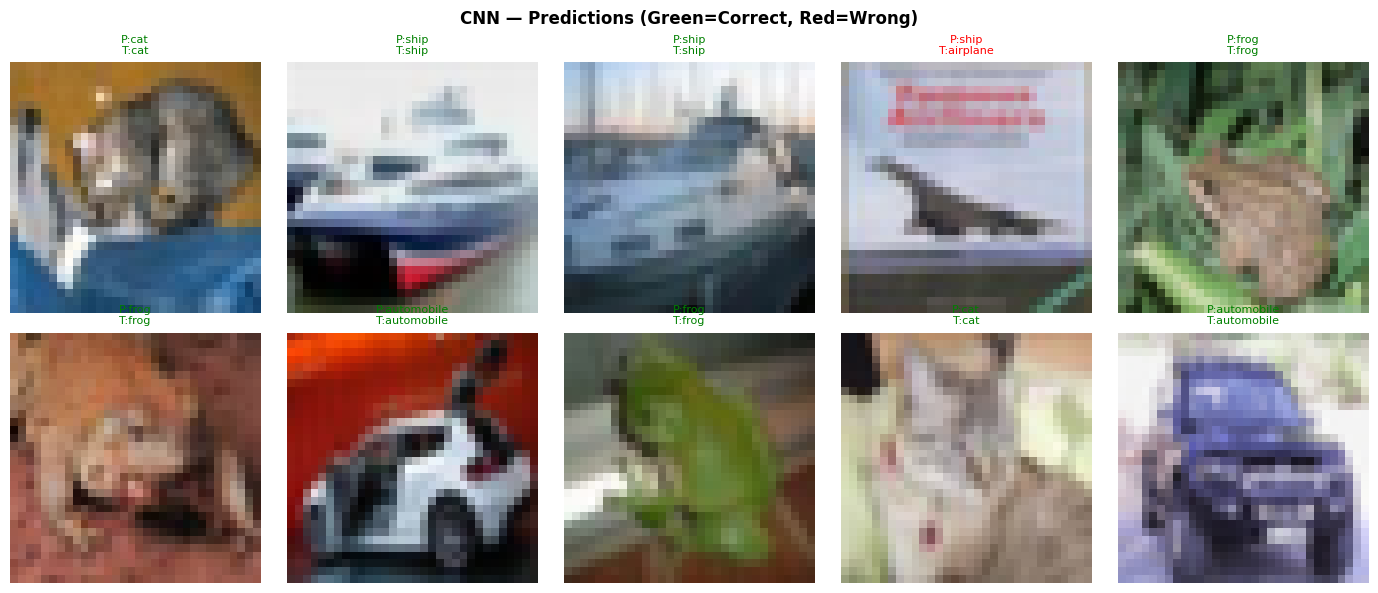

In [ ]:
def show_predictions(model, x_data, y_true_labels, model_name, n=10):
    preds = np.argmax(model.predict(x_data[:n]), axis=1)
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(x_test[i])
        color = 'green' if preds[i] == y_true_labels[i] else 'red'
        ax.set_title(f"P:{class_names[preds[i]]}\nT:{class_names[y_true_labels[i]]}",
                     color=color, fontsize=8)
        ax.axis('off')
    plt.suptitle(f'{model_name} — Predictions (Green=Correct, Red=Wrong)',
                 fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

show_predictions(ann_model, x_test_flat, y_true, "ANN")
show_predictions(cnn_model, x_test_norm, y_true, "CNN")

## 📊 Analysis & Observations

### ANN (Artificial Neural Network)
- Treats each image as a **flat 3072-dim vector** loses all spatial structure
- No understanding of local patterns (edges, textures, shapes)
- Typically achieves **~50-55% accuracy** on CIFAR-10
- Prone to overfitting despite Dropout & BatchNorm
- Much faster to train per epoch

### CNN (Convolutional Neural Network)
- Uses **convolutional filters** to extract local spatial features hierarchically
- Learns low-level (edges) → mid-level (shapes) → high-level (objects) features
- Typically achieves **~80-85% accuracy** on CIFAR-10 with augmentation
- Data augmentation (flip, rotate, zoom) significantly improves generalization
- MaxPooling adds translation invariance

### Key Takeaways
| Factor              | ANN           | CNN              |
|---------------------|---------------|------------------|
| Spatial awareness   | None          | Full             |
| Parameter efficiency| Low           | High             |
| Generalization      | Moderate      | Strong           |
| Best for images?    | No            | Yes              |

> **Conclusion**: CNNs are architecturally superior for image data due to spatial
> feature extraction, weight sharing, and translation invariance.